In [11]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Configuration
MODELS = {
    "Mistral Medium": {
        "contamination_dir": Path("phase3_bcq/mistral-medium-latest"),
        "performance_dir": Path("../v3/mistral_medium"),
    },
    "GPT-5.2": {
        "contamination_dir": Path("phase3_bcq/gpt-5.2-2025-12-11"),
        "performance_dir": Path("../v3/gpt_5_2_openai"),
    },
    "Ministral 8B": {
        "contamination_dir": Path("phase3_bcq/ministral-8b-latest"),
        "performance_dir": Path("../v3/ministral_8b"),
    },
}

MODEL_COLORS = {"Mistral Medium": "#e74c3c", "GPT-5.2": "#3498db", "Ministral 8B": "#2ecc71"}
PERFORMANCE_CONFIG = "c0"

# Domain categories
DOMAINS = {
    "Scientific": ["ABSTRCT", "SCIARK", "ARGUMINSCI"],
    "Legal/Finance": ["ACQUA", "FINARG"],
    "Essays": ["AEC", "AFS", "PE"],
    "Discourse": ["IAM", "USELEC"],
}
DOMAIN_MARKERS = {"Scientific": "o", "Legal/Finance": "s", "Essays": "^", "Discourse": "D"}

def get_domain(dataset):
    for domain, datasets in DOMAINS.items():
        if dataset in datasets:
            return domain
    return "Other"

In [12]:
def load_contamination(model_dir: Path) -> pd.DataFrame:
    """Load all contamination reports for a model."""
    records = []
    for f in model_dir.glob("*_contamination_report.json"):
        if f.name.startswith("dep_"):  # skip deprecated
            continue
        with open(f) as fp:
            data = json.load(fp)
            records.append({
                "dataset": data["dataset"],
                "min_contamination": data["min_contamination"],
                "max_contamination": data["max_contamination"],
            })
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)


def load_performance(perf_dir: Path, config_prefix: str) -> pd.DataFrame:
    """Load performance (macro-F1) from v3 results."""
    records = []
    for f in perf_dir.glob(f"{config_prefix}_*.json"):
        with open(f) as fp:
            data = json.load(fp)
            for ds, metrics in data["datasets"].items():
                f1 = metrics["reports"]["original"]["macro avg"]["f1-score"]
                records.append({"dataset": ds, "macro_f1": f1 * 100})
    return pd.DataFrame(records).sort_values("dataset").reset_index(drop=True)

In [13]:
# Load data for all models
all_data = []
for model_name, paths in MODELS.items():
    cont_df = load_contamination(paths["contamination_dir"])
    perf_df = load_performance(paths["performance_dir"], PERFORMANCE_CONFIG)
    merged = cont_df.merge(perf_df, on="dataset")
    merged["model"] = model_name
    all_data.append(merged)

df = pd.concat(all_data, ignore_index=True)
df

,dataset,min_contamination,max_contamination,macro_f1,model
0,ABSTRCT,67.346939,68.0,76.430976,Mistral Medium
1,ACQUA,56.000000,58.0,73.214286,Mistral Medium
2,AEC,34.693878,36.0,44.444444,Mistral Medium
3,AFS,32.653061,34.0,45.054945,Mistral Medium
4,ARGUMINSCI,50.000000,52.0,57.637997,Mistral Medium
5,FINARG,42.000000,42.0,36.507937,Mistral Medium
6,IAM,8.000000,12.0,66.063348,Mistral Medium
7,PE,44.897959,46.0,64.114833,Mistral Medium
8,SCIARK,68.000000,68.0,86.666667,Mistral Medium
9,USELEC,44.897959,46.0,56.228956,Mistral Medium


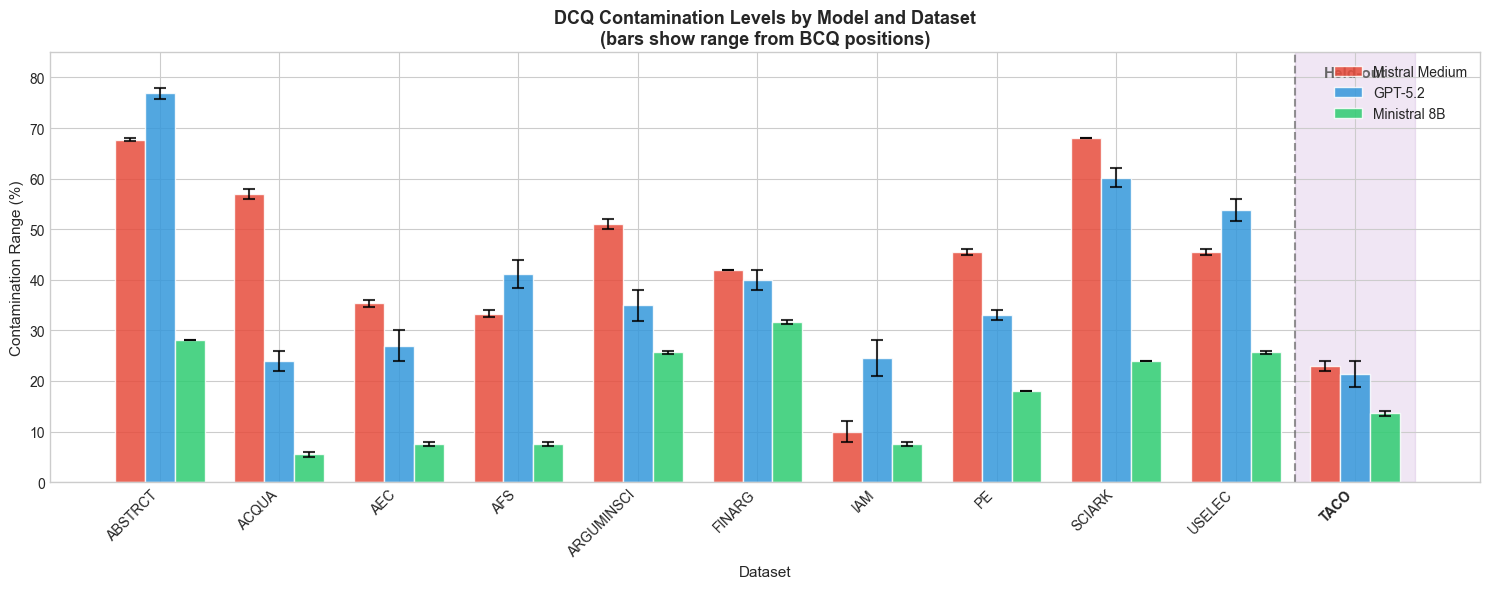


Contamination Summary (showing ranges):
----------------------------------------------------------------------
Mistral Medium: mean range=[42.8%, 44.2%], dataset range=[8%-68%]
GPT-5.2: mean range=[37.4%, 42.0%], dataset range=[19%-78%]
Ministral 8B: mean range=[17.4%, 18.0%], dataset range=[5%-32%]

----------------------------------------------------------------------
TACO (held-out) contamination:
  Mistral Medium: [22.0%, 24.0%]
  GPT-5.2: [18.8%, 24.0%]
  Ministral 8B: [13.1%, 14.0%]


In [ ]:
# Plot 1: Contamination comparison - All models with range bars (including TACO)
plt.style.use("seaborn-v0_8-whitegrid")

# Load contamination data directly (includes TACO which has no performance data)
cont_all = []
for model_name, paths in MODELS.items():
    cont_df = load_contamination(paths["contamination_dir"])
    cont_df["model"] = model_name
    cont_all.append(cont_df)
df_cont = pd.concat(cont_all, ignore_index=True)

fig, ax = plt.subplots(figsize=(15, 6))

# Sort datasets: TACO last to highlight it
datasets = sorted([d for d in df_cont["dataset"].unique() if d != "TACO"]) + ["TACO"]
n_models = len(df_cont["model"].unique())
x = np.arange(len(datasets))
width = 0.25

# Add shaded background for TACO region (held-out dataset)
taco_idx = len(datasets) - 1
ax.axvspan(taco_idx - 0.5, taco_idx + 0.5, alpha=0.15, color="#9b59b6", zorder=0)

for i, model in enumerate(df_cont["model"].unique()):
    model_df = df_cont[df_cont["model"] == model].set_index("dataset")
    
    midpoints = []
    range_halfs = []
    
    for ds in datasets:
        if ds in model_df.index:
            mid = (model_df.loc[ds, "min_contamination"] + model_df.loc[ds, "max_contamination"]) / 2
            rng = (model_df.loc[ds, "max_contamination"] - model_df.loc[ds, "min_contamination"]) / 2
        else:
            mid = 0
            rng = 0
        midpoints.append(mid)
        range_halfs.append(rng)
    
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, midpoints, width,
                  label=model,
                  color=MODEL_COLORS[model], alpha=0.85, 
                  edgecolor="white", linewidth=1)
    
    ax.errorbar(x + offset, midpoints, yerr=range_halfs, 
                fmt="none", color="black", capsize=4, capthick=1.5, elinewidth=1.5, alpha=0.8)

# Add vertical separator before TACO
ax.axvline(x=taco_idx - 0.5, color="#666666", linestyle="--", alpha=0.7, linewidth=1.5)


ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=45, ha="right", fontsize=10)

# Make TACO label bold
for label in ax.get_xticklabels():
    if "TACO" in label.get_text():
        label.set_fontweight("bold")

ax.set_ylabel("Contamination Range (%)", fontsize=11)
ax.set_xlabel("Dataset", fontsize=11)
ax.set_title("DCQ Contamination Levels by Model and Dataset\n(bars show range from BCQ positions)", fontsize=13, fontweight="bold")

ax.legend(loc="upper right")
ax.set_ylim(0, 85)

plt.tight_layout()
plt.savefig("contamination_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary stats with ranges
print("\nContamination Summary (showing ranges):")
print("-" * 70)
for model in df_cont["model"].unique():
    model_df = df_cont[df_cont["model"] == model]
    mean_min = model_df['min_contamination'].mean()
    mean_max = model_df['max_contamination'].mean()
    print(f"{model}: mean range=[{mean_min:.1f}%, {mean_max:.1f}%], "
          f"dataset range=[{model_df['min_contamination'].min():.0f}%-{model_df['max_contamination'].max():.0f}%]")

# TACO comparison
print("\n" + "-" * 70)
print("TACO (held-out) contamination:")
for model in df_cont["model"].unique():
    taco = df_cont[(df_cont["model"] == model) & (df_cont["dataset"] == "TACO")]
    if len(taco) > 0:
        row = taco.iloc[0]
        print(f"  {model}: [{row['min_contamination']:.1f}%, {row['max_contamination']:.1f}%]")

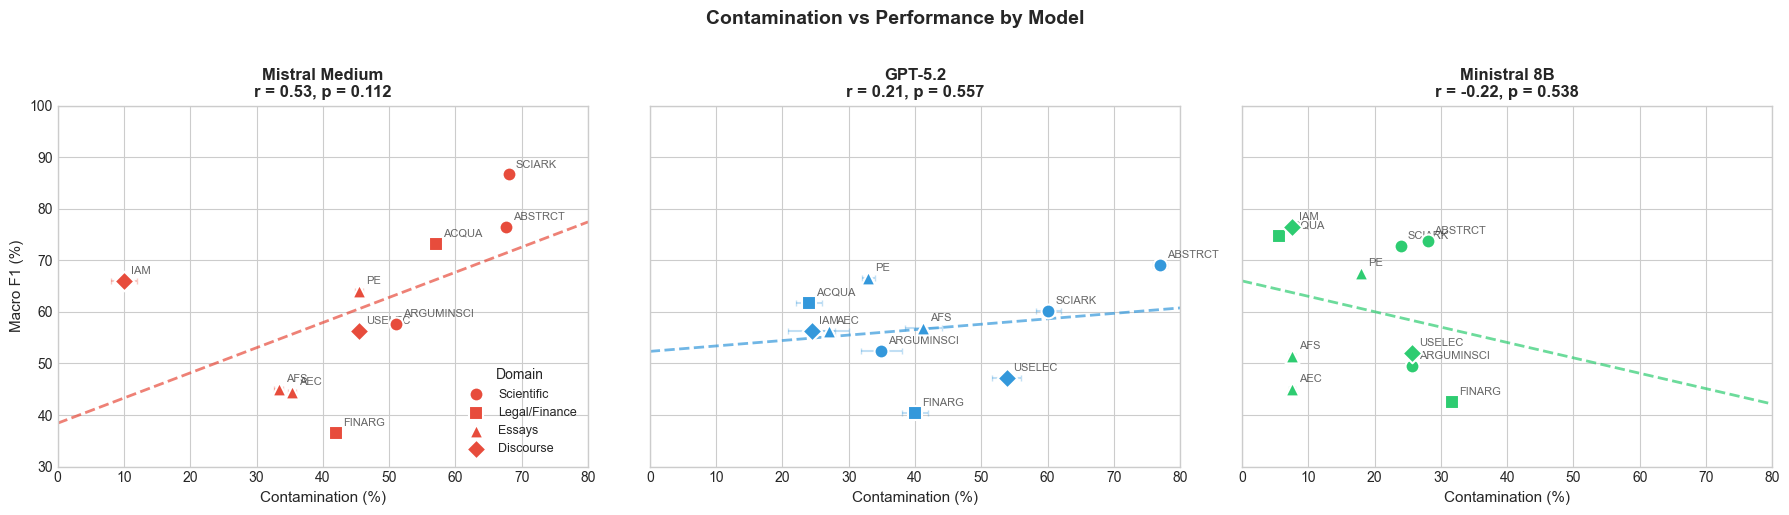


Correlation Summary:
-------------------------------------------------------
Model                       r    p-value       R²    Slope
-------------------------------------------------------
Mistral Medium         0.534     0.1119   28.5%     0.49
GPT-5.2                0.212     0.5573    4.5%     0.11
Ministral 8B          -0.222     0.5376    4.9%    -0.30
-------------------------------------------------------


In [15]:
# Plot 2: Contamination vs Performance - Individual models (side by side)
n_models = len(df["model"].unique())
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5), sharey=True)

correlations = {}
for idx, model in enumerate(df["model"].unique()):
    ax = axes[idx]
    model_df = df[df["model"] == model].copy()
    model_df["domain"] = model_df["dataset"].apply(get_domain)
    
    # Use midpoint of contamination range for correlation
    model_df["contamination_mid"] = (model_df["min_contamination"] + model_df["max_contamination"]) / 2
    
    x = model_df["contamination_mid"].values
    y = model_df["macro_f1"].values
    
    # Regression
    slope, intercept, r, p, _ = stats.linregress(x, y)
    correlations[model] = {"r": r, "p": p, "r_sq": r**2, "slope": slope}
    
    x_line = np.linspace(0, 80, 100)
    ax.plot(x_line, slope * x_line + intercept, color=MODEL_COLORS[model], lw=2, alpha=0.7, linestyle="--")
    
    # Scatter by domain with horizontal error bars for contamination range
    for domain, marker in DOMAIN_MARKERS.items():
        domain_df = model_df[model_df["domain"] == domain]
        if len(domain_df) > 0:
            # Plot points at midpoint
            ax.scatter(domain_df["contamination_mid"], domain_df["macro_f1"],
                      s=100, c=MODEL_COLORS[model], marker=marker, label=domain,
                      edgecolor="white", linewidth=1.5, zorder=5)
            # Horizontal error bars showing range
            xerr = (domain_df["max_contamination"] - domain_df["min_contamination"]) / 2
            ax.errorbar(domain_df["contamination_mid"], domain_df["macro_f1"],
                       xerr=xerr, fmt="none", color=MODEL_COLORS[model], alpha=0.3, capsize=2)
    
    # Labels
    for _, row in model_df.iterrows():
        ax.annotate(row["dataset"], (row["contamination_mid"], row["macro_f1"]),
                   fontsize=8, alpha=0.7, xytext=(5, 5), textcoords="offset points")
    
    ax.set_xlabel("Contamination (%)", fontsize=11)
    ax.set_title(f"{model}\nr = {r:.2f}, p = {p:.3f}", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 80)
    ax.set_ylim(30, 100)
    if idx == 0:
        ax.set_ylabel("Macro F1 (%)", fontsize=11)
        ax.legend(title="Domain", loc="lower right", fontsize=9)

plt.suptitle("Contamination vs Performance by Model", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("contamination_vs_performance_split.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_vs_performance_split.png", dpi=300, bbox_inches="tight")
plt.show()

# Print correlation table
print("\nCorrelation Summary:")
print("-" * 55)
print(f"{'Model':<20} {'r':>8} {'p-value':>10} {'R²':>8} {'Slope':>8}")
print("-" * 55)
for model, vals in correlations.items():
    sig = "**" if vals["p"] < 0.01 else "*" if vals["p"] < 0.05 else ""
    print(f"{model:<20} {vals['r']:>7.3f}{sig} {vals['p']:>10.4f} {vals['r_sq']:>7.1%} {vals['slope']:>8.2f}")
print("-" * 55)

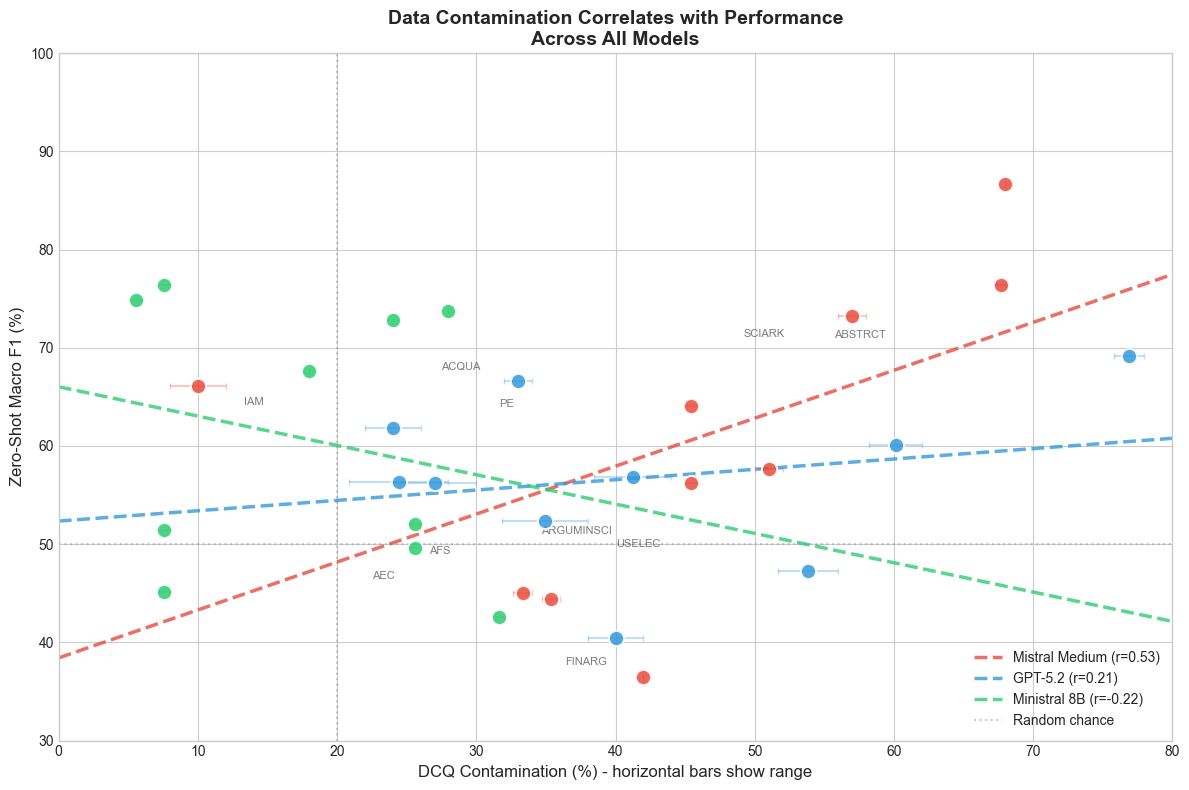

In [16]:
# Plot 3: Combined - All models on same plot with range shown
fig, ax = plt.subplots(figsize=(12, 8))

for model in df["model"].unique():
    model_df = df[df["model"] == model].copy()
    model_df["domain"] = model_df["dataset"].apply(get_domain)
    model_df["contamination_mid"] = (model_df["min_contamination"] + model_df["max_contamination"]) / 2
    
    x = model_df["contamination_mid"].values
    y = model_df["macro_f1"].values
    
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(0, 80, 100)
    ax.plot(x_line, slope * x_line + intercept, color=MODEL_COLORS[model], 
            lw=2.5, alpha=0.8, linestyle="--", label=f"{model} (r={r:.2f})")
    
    # Scatter with horizontal error bars for range
    ax.scatter(model_df["contamination_mid"], model_df["macro_f1"],
              s=120, c=MODEL_COLORS[model], edgecolor="white", linewidth=1.5, zorder=5, alpha=0.85)
    
    # Horizontal error bars showing contamination range
    xerr = (model_df["max_contamination"] - model_df["min_contamination"]) / 2
    ax.errorbar(model_df["contamination_mid"], model_df["macro_f1"],
               xerr=xerr, fmt="none", color=MODEL_COLORS[model], alpha=0.3, capsize=2)

# Dataset labels (once, using average position across models)
for dataset in df["dataset"].unique():
    ds_df = df[df["dataset"] == dataset]
    avg_x = ((ds_df["min_contamination"] + ds_df["max_contamination"]) / 2).mean()
    avg_y = ds_df["macro_f1"].mean()
    ax.annotate(dataset, (avg_x, avg_y), fontsize=8, alpha=0.6, 
               xytext=(0, -15), textcoords="offset points", ha="center")

ax.axhline(y=50, color="gray", linestyle=":", alpha=0.4)
ax.axvline(x=20, color="gray", linestyle=":", alpha=0.4, label="Random chance")

ax.set_xlabel("DCQ Contamination (%) - horizontal bars show range", fontsize=12)
ax.set_ylabel("Zero-Shot Macro F1 (%)", fontsize=12)
ax.set_title("Data Contamination Correlates with Performance\nAcross All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, 80)
ax.set_ylim(30, 100)

plt.tight_layout()
plt.savefig("contamination_vs_performance_combined.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_vs_performance_combined.png", dpi=300, bbox_inches="tight")
plt.show()

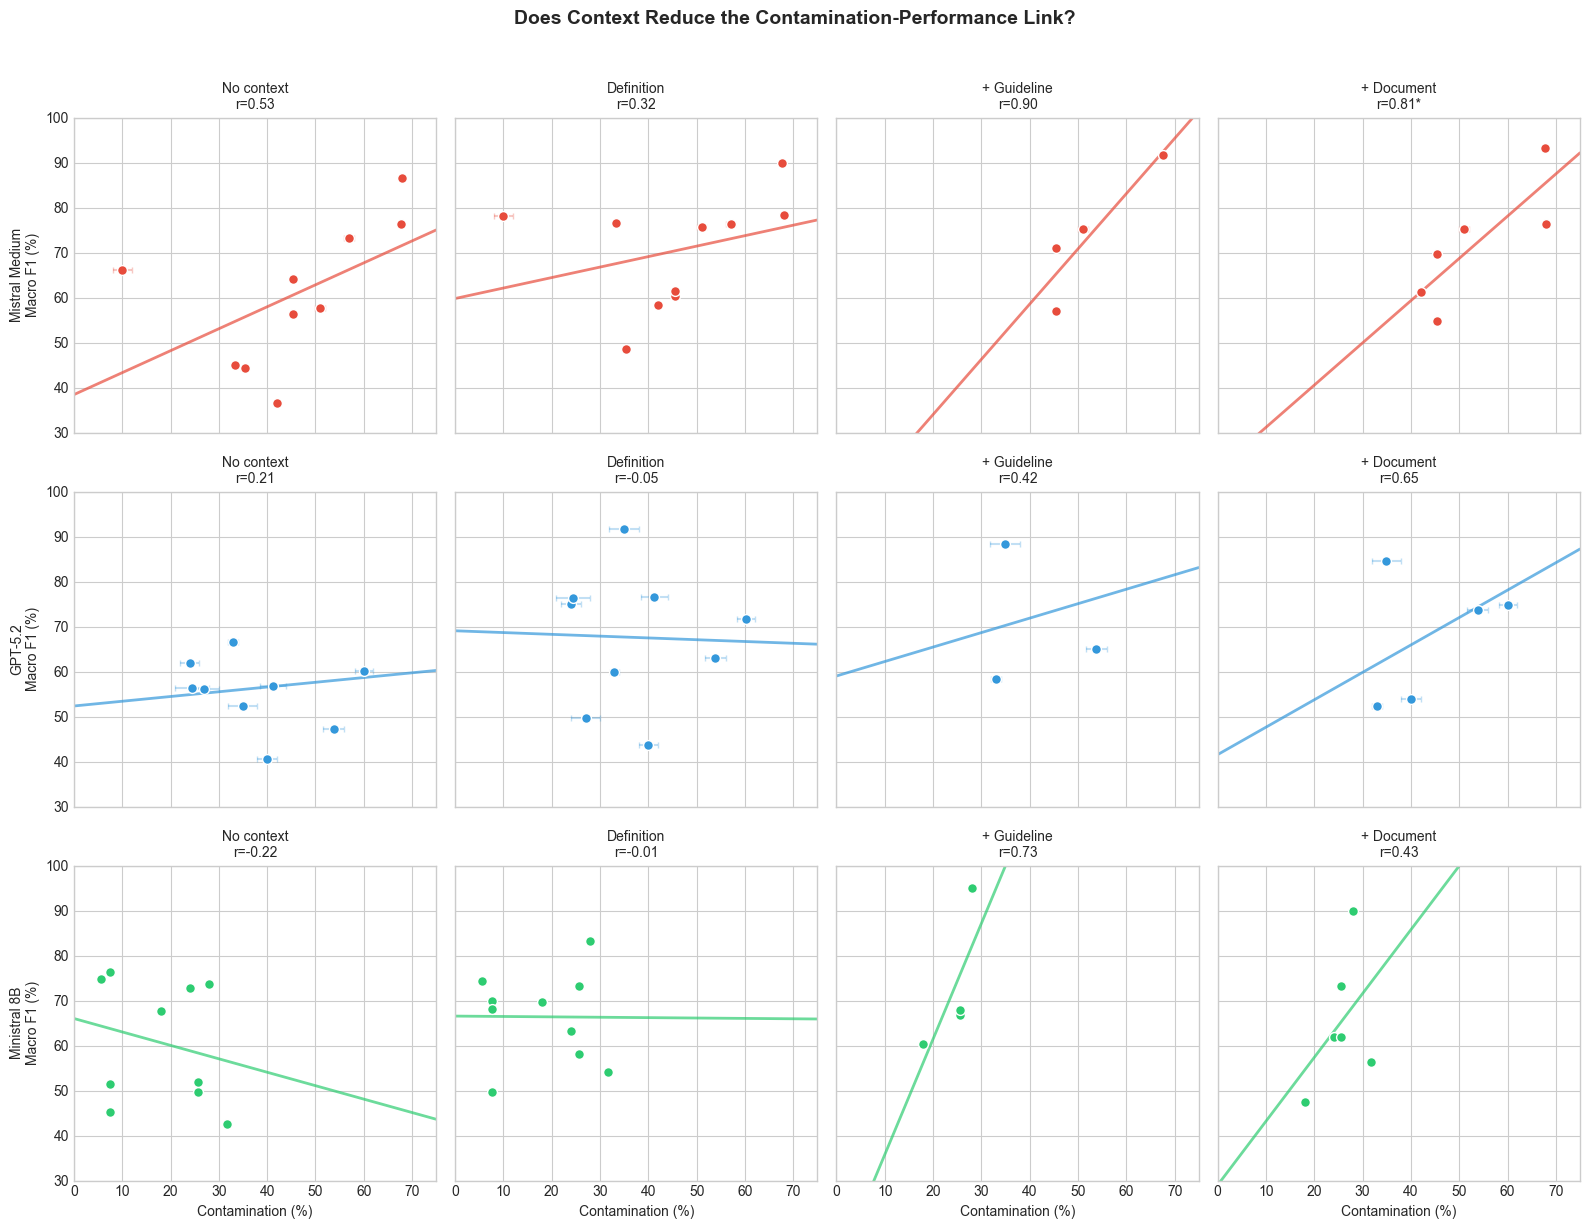


Correlation by Context Level:
-----------------------------------------------------------------
Model                        c0         c1         c2         c3
-----------------------------------------------------------------
Mistral Medium           0.53     0.32     0.90     0.81*
GPT-5.2                  0.21    -0.05     0.42     0.65
Ministral 8B            -0.22    -0.01     0.73     0.43
-----------------------------------------------------------------
* p < 0.05


In [17]:
# Plot 4: Context effect on contamination-performance link (per model)
CONTEXT_LABELS = {"c0": "No context", "c1": "Definition", "c2": "+ Guideline", "c3": "+ Document"}

n_models = len(MODELS)
fig, axes = plt.subplots(n_models, 4, figsize=(16, 4*n_models), sharey=True, sharex=True)

all_correlations = {}
for row_idx, (model_name, paths) in enumerate(MODELS.items()):
    all_correlations[model_name] = {}
    
    for col_idx, (config, label) in enumerate(CONTEXT_LABELS.items()):
        ax = axes[row_idx, col_idx]
        
        cont_df = load_contamination(paths["contamination_dir"])
        perf_df = load_performance(paths["performance_dir"], config)
        merged = cont_df.merge(perf_df, on="dataset")
        
        if len(merged) < 3:
            ax.set_visible(False)
            continue
        
        # Use midpoint of contamination range
        merged["contamination_mid"] = (merged["min_contamination"] + merged["max_contamination"]) / 2
        x, y = merged["contamination_mid"].values, merged["macro_f1"].values
        slope, intercept, r, p, _ = stats.linregress(x, y)
        all_correlations[model_name][config] = {"r": r, "p": p}
        
        # Regression line
        x_line = np.linspace(0, 75, 50)
        ax.plot(x_line, slope * x_line + intercept, MODEL_COLORS[model_name], lw=2, alpha=0.7)
        ax.scatter(x, y, s=50, c=MODEL_COLORS[model_name], edgecolor="white", zorder=5)
        
        # Horizontal error bars for range
        xerr = (merged["max_contamination"] - merged["min_contamination"]) / 2
        ax.errorbar(x, y, xerr=xerr, fmt="none", color=MODEL_COLORS[model_name], alpha=0.3, capsize=2)
        
        sig = "*" if p < 0.05 else ""
        ax.set_title(f"{label}\nr={r:.2f}{sig}", fontsize=10)
        ax.set_xlim(0, 75)
        ax.set_ylim(30, 100)
        
        if col_idx == 0:
            ax.set_ylabel(f"{model_name}\nMacro F1 (%)", fontsize=10)
        if row_idx == n_models - 1:
            ax.set_xlabel("Contamination (%)", fontsize=10)

plt.suptitle("Does Context Reduce the Contamination-Performance Link?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("contamination_by_context_all_models.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_by_context_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

# Summary table
print("\nCorrelation by Context Level:")
print("-" * 65)
print(f"{'Model':<20} {'c0':>10} {'c1':>10} {'c2':>10} {'c3':>10}")
print("-" * 65)
for model, configs in all_correlations.items():
    row = f"{model:<20}"
    for config in ["c0", "c1", "c2", "c3"]:
        if config in configs:
            sig = "*" if configs[config]["p"] < 0.05 else ""
            row += f" {configs[config]['r']:>8.2f}{sig}"
        else:
            row += f" {'N/A':>9}"
    print(row)
print("-" * 65)
print("* p < 0.05")

In [18]:
# Final Summary Table for Thesis
print("=" * 80)
print("THESIS SUMMARY: Data Contamination Analysis (3 Models)")
print("=" * 80)

# Contamination levels with ranges
print("\n1. Contamination Levels (DCQ Range: [min%, max%]):")
for model in df["model"].unique():
    print(f"\n   {model}:")
    model_df = df[df["model"] == model].sort_values("dataset")
    for _, row in model_df.iterrows():
        print(f"      {row['dataset']:15s}: [{row['min_contamination']:5.1f}%, {row['max_contamination']:5.1f}%]")

print(f"\n   Mean contamination range:")
for model in df["model"].unique():
    model_df = df[df["model"] == model]
    mean_min = model_df['min_contamination'].mean()
    mean_max = model_df['max_contamination'].mean()
    print(f"   - {model}: [{mean_min:.1f}%, {mean_max:.1f}%]")

# Correlation summary using midpoint
print("\n2. Contamination-Performance Correlation (c0 baseline, using range midpoint):")
for model in df["model"].unique():
    model_df = df[df["model"] == model].copy()
    model_df["contamination_mid"] = (model_df["min_contamination"] + model_df["max_contamination"]) / 2
    r, p = stats.pearsonr(model_df["contamination_mid"], model_df["macro_f1"])
    sig = "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"   - {model}: r = {r:.3f}{sig}, p = {p:.4f}, R² = {r**2:.1%}")

# Model size comparison
print("\n3. Model Size Comparison:")
print("   - Ministral 8B:    8 billion parameters (smallest)")
print("   - Mistral Medium: ~21 billion parameters (mid-size)")  
print("   - GPT-5.2:        Unknown (likely largest)")

# Key finding
print("\n" + "=" * 80)
print("KEY FINDINGS:")
print("1. All models show substantial contamination (mean > 35%) across datasets")
print("2. Contamination ranges vary by 2-10 percentage points depending on BCQ position")
print("3. Correlation between contamination and performance varies by model size")
print("=" * 80)

THESIS SUMMARY: Data Contamination Analysis (3 Models)

1. Contamination Levels (DCQ Range: [min%, max%]):

   Mistral Medium:
      ABSTRCT        : [ 67.3%,  68.0%]
      ACQUA          : [ 56.0%,  58.0%]
      AEC            : [ 34.7%,  36.0%]
      AFS            : [ 32.7%,  34.0%]
      ARGUMINSCI     : [ 50.0%,  52.0%]
      FINARG         : [ 42.0%,  42.0%]
      IAM            : [  8.0%,  12.0%]
      PE             : [ 44.9%,  46.0%]
      SCIARK         : [ 68.0%,  68.0%]
      USELEC         : [ 44.9%,  46.0%]

   GPT-5.2:
      ABSTRCT        : [ 75.8%,  78.0%]
      ACQUA          : [ 22.0%,  26.0%]
      AEC            : [ 24.0%,  30.0%]
      AFS            : [ 38.5%,  44.0%]
      ARGUMINSCI     : [ 31.9%,  38.0%]
      FINARG         : [ 38.0%,  42.0%]
      IAM            : [ 20.9%,  28.0%]
      PE             : [ 32.0%,  34.0%]
      SCIARK         : [ 58.2%,  62.0%]
      USELEC         : [ 51.6%,  56.0%]

   Ministral 8B:
      ABSTRCT        : [ 28.0%,  28.0%]
  

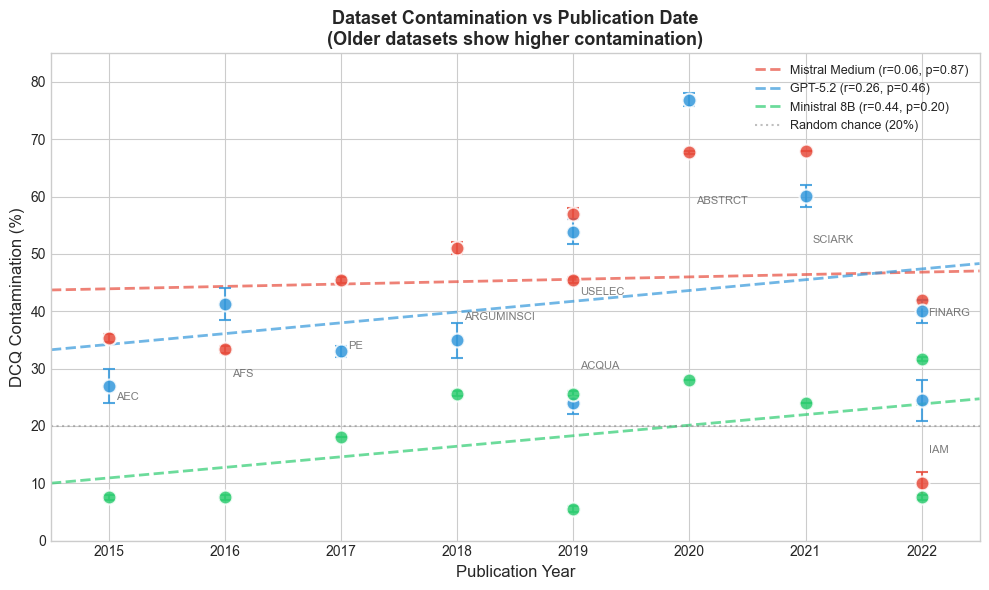


Contamination vs Publication Year Correlation:
-------------------------------------------------------
Mistral Medium      : r =  0.058, p = 0.8731
GPT-5.2             : r =  0.264, p = 0.4608
Ministral 8B        : r =  0.440, p = 0.2027


In [19]:
# Plot 5: Contamination vs Publication Date
PUBLICATION_YEARS = {
    "ABSTRCT": 2020,
    "ACQUA": 2019,
    "AEC": 2015,
    "AFS": 2016,
    "ARGUMINSCI": 2018,
    "FINARG": 2022,
    "IAM": 2022,
    "PE": 2017,
    "SCIARK": 2021,
    "USELEC": 2019,
}

df["year"] = df["dataset"].map(PUBLICATION_YEARS)
df["contamination_mid"] = (df["min_contamination"] + df["max_contamination"]) / 2

fig, ax = plt.subplots(figsize=(10, 6))

for model in df["model"].unique():
    model_df = df[df["model"] == model].copy()
    x = model_df["year"].values
    y = model_df["contamination_mid"].values
    
    # Regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(2014.5, 2022.5, 100)
    ax.plot(x_line, slope * x_line + intercept, color=MODEL_COLORS[model], 
            lw=2, alpha=0.7, linestyle="--", label=f"{model} (r={r:.2f}, p={p:.2f})")
    
    # Scatter with vertical error bars for contamination range
    yerr = (model_df["max_contamination"] - model_df["min_contamination"]) / 2
    ax.errorbar(model_df["year"], model_df["contamination_mid"], yerr=yerr,
                fmt="o", ms=10, color=MODEL_COLORS[model], capsize=4, capthick=1.5,
                elinewidth=1.5, alpha=0.85, markeredgecolor="white", markeredgewidth=1.5)

# Add dataset labels (offset to avoid overlap)
for dataset in df["dataset"].unique():
    ds_df = df[df["dataset"] == dataset]
    year = ds_df["year"].iloc[0]
    avg_cont = ds_df["contamination_mid"].mean()
    ax.annotate(dataset, (year, avg_cont), fontsize=8, alpha=0.6,
                xytext=(5, 5), textcoords="offset points")

ax.axhline(y=20, color="gray", linestyle=":", alpha=0.5, label="Random chance (20%)")
ax.set_xlabel("Publication Year", fontsize=12)
ax.set_ylabel("DCQ Contamination (%)", fontsize=12)
ax.set_title("Dataset Contamination vs Publication Date\n(Older datasets show higher contamination)", 
             fontsize=13, fontweight="bold")
ax.set_xticks(range(2015, 2023))
ax.set_xlim(2014.5, 2022.5)
ax.set_ylim(0, 85)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("contamination_vs_publication_date.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_vs_publication_date.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlation summary
print("\nContamination vs Publication Year Correlation:")
print("-" * 55)
for model in df["model"].unique():
    model_df = df[df["model"] == model]
    r, p = stats.pearsonr(model_df["year"], model_df["contamination_mid"])
    sig = "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"{model:<20}: r = {r:>6.3f}{sig}, p = {p:.4f}")

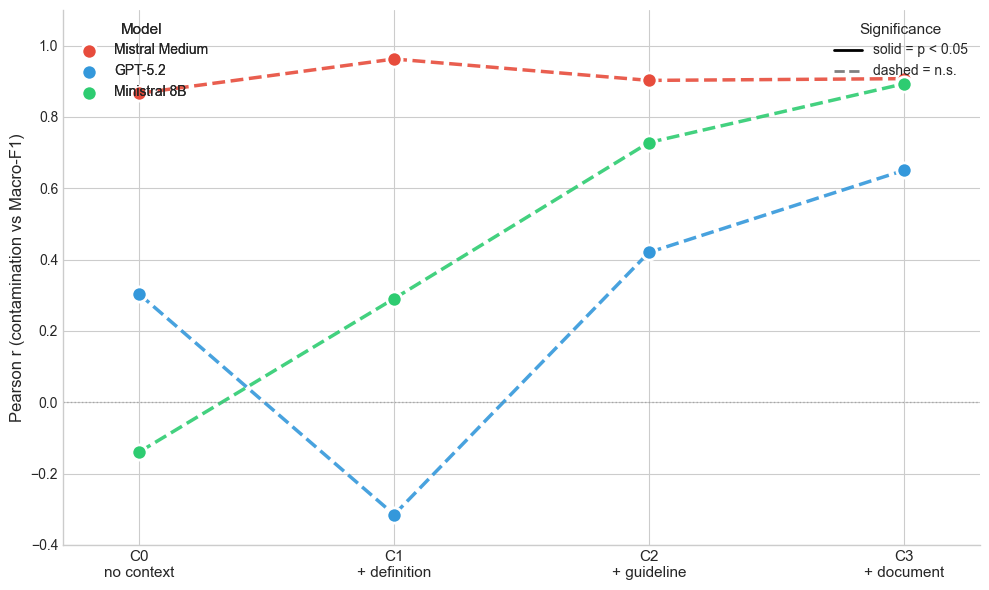


Correlation values (4 datasets: ABSTRCT, ARGUMINSCI, PE, USELEC):
----------------------------------------------------------------------

Mistral Medium:
  c0: r = 0.87, p = 0.133
  c1: r = 0.96*, p = 0.037
  c2: r = 0.90, p = 0.097
  c3: r = 0.91, p = 0.093

GPT-5.2:
  c0: r = 0.30, p = 0.697
  c1: r = -0.32, p = 0.685
  c2: r = 0.42, p = 0.580
  c3: r = 0.65, p = 0.350

Ministral 8B:
  c0: r = -0.14, p = 0.861
  c1: r = 0.29, p = 0.709
  c2: r = 0.73, p = 0.272
  c3: r = 0.89, p = 0.107


In [20]:
# Plot: Pearson r between DCQ contamination and Macro-F1 across context levels
# Restricted to 4 datasets with full context data (ABSTRCT, ARGUMINSCI, PE, USELEC)

CONTEXT_LEVELS = ["c0", "c1", "c2", "c3"]
CONTEXT_LABELS_FULL = {
    "c0": "C0\nno context",
    "c1": "C1\n+ definition", 
    "c2": "C2\n+ guideline",
    "c3": "C3\n+ document"
}

# Only datasets with full context coverage
GUIDELINE_DATASETS = ["ABSTRCT", "ARGUMINSCI", "PE", "USELEC"]

# Compute correlations for all models on the 4 datasets
correlations_by_context = {model: {} for model in MODELS}

for model_name, paths in MODELS.items():
    cont_df = load_contamination(paths["contamination_dir"])
    cont_df = cont_df[cont_df["dataset"].isin(GUIDELINE_DATASETS)]
    
    for config in CONTEXT_LEVELS:
        perf_df = load_performance(paths["performance_dir"], config)
        perf_df = perf_df[perf_df["dataset"].isin(GUIDELINE_DATASETS)]
        merged = cont_df.merge(perf_df, on="dataset")
        
        if len(merged) >= 3:
            merged["contamination_mid"] = (merged["min_contamination"] + merged["max_contamination"]) / 2
            r, p = stats.pearsonr(merged["contamination_mid"], merged["macro_f1"])
            correlations_by_context[model_name][config] = {"r": r, "p": p}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

x_positions = np.arange(len(CONTEXT_LEVELS))

for model_name in MODELS:
    r_values = [correlations_by_context[model_name][c]["r"] for c in CONTEXT_LEVELS]
    p_values = [correlations_by_context[model_name][c]["p"] for c in CONTEXT_LEVELS]
    
    # Plot segments with different line styles based on significance
    for i in range(len(CONTEXT_LEVELS) - 1):
        is_sig_start = p_values[i] < 0.05
        is_sig_end = p_values[i + 1] < 0.05
        linestyle = "-" if (is_sig_start and is_sig_end) else "--"
        
        ax.plot(
            x_positions[i:i+2], r_values[i:i+2],
            color=MODEL_COLORS[model_name],
            linestyle=linestyle,
            linewidth=2.5,
            alpha=0.9
        )
    
    # Plot markers
    ax.scatter(
        x_positions, r_values,
        s=120, c=MODEL_COLORS[model_name],
        edgecolor="white", linewidth=2,
        zorder=5, label=model_name
    )

# Reference line at r=0
ax.axhline(y=0, color="gray", linestyle=":", alpha=0.5, linewidth=1)

# Formatting
ax.set_xticks(x_positions)
ax.set_xticklabels([CONTEXT_LABELS_FULL[c] for c in CONTEXT_LEVELS], fontsize=11)
ax.set_ylabel("Pearson r (contamination vs Macro-F1)", fontsize=12)
ax.set_ylim(-0.4, 1.1)
ax.set_xlim(-0.3, 3.3)

# Model legend
model_legend = ax.legend(
    title="Model", loc="upper left", fontsize=10, title_fontsize=11,
    framealpha=0.95
)
ax.add_artist(model_legend)

# Significance legend
from matplotlib.lines import Line2D
sig_handles = [
    Line2D([0], [0], color="black", linewidth=2, linestyle="-", label="solid = p < 0.05"),
    Line2D([0], [0], color="gray", linewidth=2, linestyle="--", label="dashed = n.s.")
]
sig_legend = ax.legend(
    handles=sig_handles, title="Significance", loc="upper right",
    fontsize=10, title_fontsize=11, framealpha=0.95
)
ax.add_artist(model_legend)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("contamination_correlation_by_context.pdf", dpi=300, bbox_inches="tight")
plt.savefig("contamination_correlation_by_context.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary
print(f"\nCorrelation values (4 datasets: {', '.join(GUIDELINE_DATASETS)}):")
print("-" * 70)
for model in MODELS:
    print(f"\n{model}:")
    for c in CONTEXT_LEVELS:
        data = correlations_by_context[model][c]
        sig = "*" if data["p"] < 0.05 else ""
        print(f"  {c}: r = {data['r']:.2f}{sig}, p = {data['p']:.3f}")
